In [2]:
# mount drive if needed
from google.colab import drive
drive.mount('/gdrive')
# CD to your working directory to upload images or download the sample image below

Mounted at /gdrive


# Download a sample aerial image

The sample image is an aerial image captured over Kala Nera, Greece with a spatial resolution of 13cm

In [3]:
import os
import urllib.request

# Define directory and filename
save_dir = "/content/images"
filename = "roi_kala.tif"

# Create the directory if it doesn't exist
os.makedirs(save_dir, exist_ok=True)

# Add all images here
# Define the image URL
image_url = "https://raw.githubusercontent.com/MohanadDiab/langrs/main/data/roi_kala.tif"

# Download the image
image_path = os.path.join(save_dir, filename)
urllib.request.urlretrieve(image_url, image_path)

print(f"Image downloaded to: {image_path}")


Image downloaded to: /content/images/roi_kala.tif


Display the aerial image

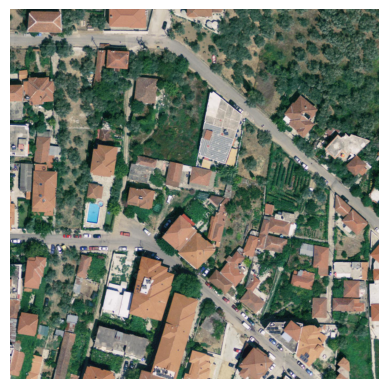

In [4]:
# display the image
import matplotlib.pyplot as plt
from PIL import Image
image = Image.open(image_path)
plt.imshow(image)
plt.axis('off')
plt.show()

# Install LangRS

In [5]:
!pip install langrs --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.3/82.3 kB 5.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.8/46.8 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 157.2/157.2 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.0/102.0 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 256.2/256.2 kB 16.9 MB/s eta 0:00:00


# Setting the parameters
In this notebook, we provide an example of how to use the langrs package using an image and a text input.


*   The image input is provided as a tif file, and the text input is the object to be segmented in the provided aerial image.

*   Grounding Dino is used first to provide bounding boxes for the object specified in the text input

* Outlier rejection is then applied to the resulting bounding boxes to filter out the non-homogenous sized bounding boxes.

* Segment Anything Model (SAM) is then used to produce the segmentation masks, utilizing the boudnding boxes resulting from the previous steps.

* Finally, visualization is provided to both our segmentation output and the segmentation output of the SamGeo output. A qualitative anlysis shows that the techniques deployed in our approach achieves better results in a setting where objects of homogenous sizes are to be segmented.





Install the package using pip

3 main inputs are required when an instance is to be initiated:

1. image: String that indicates the path to the input Tiff file.
2. prompt: A string representing the object of interest that needs to be segmented in the aerial image.
3. output_path: An output folder path, a folder with a timestamp will be created in this folder which will hold all the plots.

In [6]:
prompt = 'roof'
output_path = 'output'
seg_params = {"box_threshold": 0.25, "text_threshold": 0.25}

In [14]:
import torch
from transformers import BertModel
from transformers.modeling_utils import ModuleUtilsMixin

def get_extended_attention_mask(self, attention_mask, input_shape, device=None, dtype=None):
    if dtype is None:
        dtype = self.dtype
    if attention_mask.dim() == 3:
        ext = attention_mask[:, None, :, :]
    elif attention_mask.dim() == 2:
        ext = attention_mask[:, None, None, :]
    else:
        raise ValueError(f"Wrong attention_mask shape: {attention_mask.shape}")
    ext = ext.to(dtype=dtype)
    return (1.0 - ext) * torch.finfo(dtype).min

ModuleUtilsMixin.get_extended_attention_mask = get_extended_attention_mask

# patch précédent (get_head_mask), à garder
if not hasattr(BertModel, "get_head_mask"):
    def get_head_mask(self, head_mask, num_hidden_layers, is_attention_chunked=False):
        return [None] * num_hidden_layers if head_mask is None else head_mask
    BertModel.get_head_mask = get_head_mask

In [11]:
from transformers import BertModel

if not hasattr(BertModel, "get_head_mask"):
    def get_head_mask(self, head_mask, num_hidden_layers, is_attention_chunked=False):
        return [None] * num_hidden_layers if head_mask is None else head_mask
    BertModel.get_head_mask = get_head_mask

from samgeo.text_sam import LangSAM
sam = LangSAM()

final text_encoder_type: bert-base-uncased


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

groundingdino_swinb_cogcoor.pth: reconstructing file:   0%|          |  0.00B /  938MB            

groundingdino_swinb_cogcoor.pth: downloading bytes:           |  0.00B            

Downloading: "https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth" to /root/.cache/torch/hub/checkpoints/sam_vit_h_4b8939.pth


100%|██████████| 2.39G/2.39G [00:58<00:00, 43.7MB/s]


# SamGeo

In [15]:
from samgeo.text_sam import LangSAM
samgeo = LangSAM()

final text_encoder_type: bert-base-uncased


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

In [16]:
samgeo.predict(image_path, prompt, **seg_params)

In [17]:
samgeo_bb = samgeo.boxes.tolist()

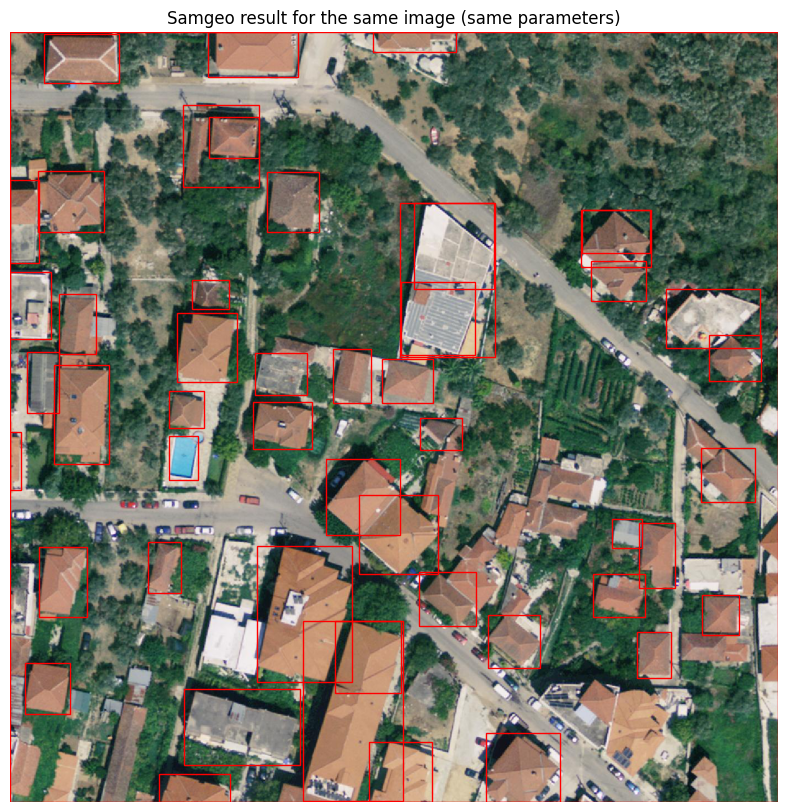

In [18]:
samgeo.show_anns(
    cmap="viridis",
    add_boxes=True,
    alpha=0,
    title="Samgeo result for the same image (same parameters)",
)

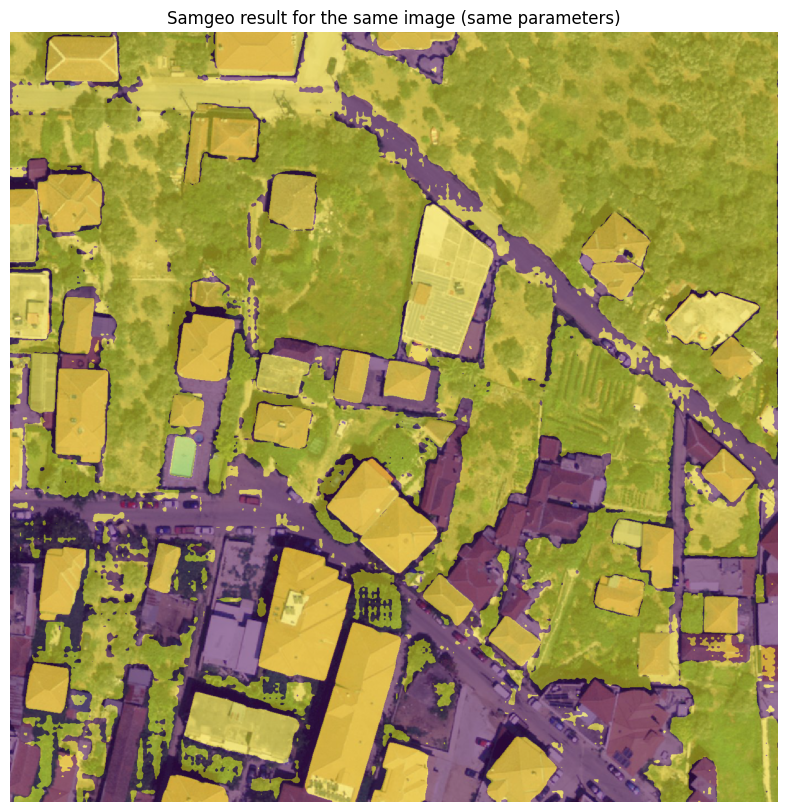

In [19]:
samgeo_masks = samgeo.masks
samgeo.show_anns(
    cmap="viridis",
    add_boxes=False,
    alpha=0.5,
    title="Samgeo result for the same image (same parameters)",
)

#LangRS

Import LangRS

In [20]:
from langrs import LangRS

In [21]:
model = LangRS(image=image_path, prompt=prompt, output_path=output_path)

final text_encoder_type: bert-base-uncased


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Now, we are going to generate the bounding boxes.

However, unlike SamGeo, the inference is not going to be done on the entire image, instead, it will be done on smaller 'chunks' of the input images based on the sliding window.

In [23]:
import gc, torch

# garde ce dont tu as besoin pour la comparaison finale
samgeo_bb = samgeo.boxes.tolist()

del samgeo
gc.collect()
torch.cuda.empty_cache()

print(f"Mémoire allouée : {torch.cuda.memory_allocated()/1e9:.2f} Go")

Mémoire allouée : 7.57 Go


In [24]:
bounding_boxes = model.generate_boxes(window_size=600, overlap=300, **seg_params)

In [25]:
input_image = model.pil_image

In [26]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

def plot_bounding_boxes(image, bounding_boxes, box_color='r', linewidth=1, figsize=(10, 10), title="Bounding Boxes"):
    """
    Plots bounding boxes on an input image.

    Parameters:
    - image: PIL or numpy image to be displayed.
    - bounding_boxes: List of bounding boxes in (x_min, y_min, x_max, y_max) format.
    - box_color: Color of the bounding boxes (default: 'r' for red).
    - linewidth: Thickness of the bounding box lines (default: 1).
    - figsize: Size of the figure (default: (10, 10)).
    - title: Title of the plot (default: "Bounding Boxes").
    """
    fig, ax = plt.subplots(figsize=figsize)
    ax.axis('off')
    ax.imshow(image)
    ax.set_title(title)

    for box in bounding_boxes:
        x_min, y_min, x_max, y_max = box
        width = x_max - x_min
        height = y_max - y_min
        rect = Rectangle((x_min, y_min), width, height, linewidth=linewidth, edgecolor=box_color, facecolor='none')
        ax.add_patch(rect)

    plt.show()

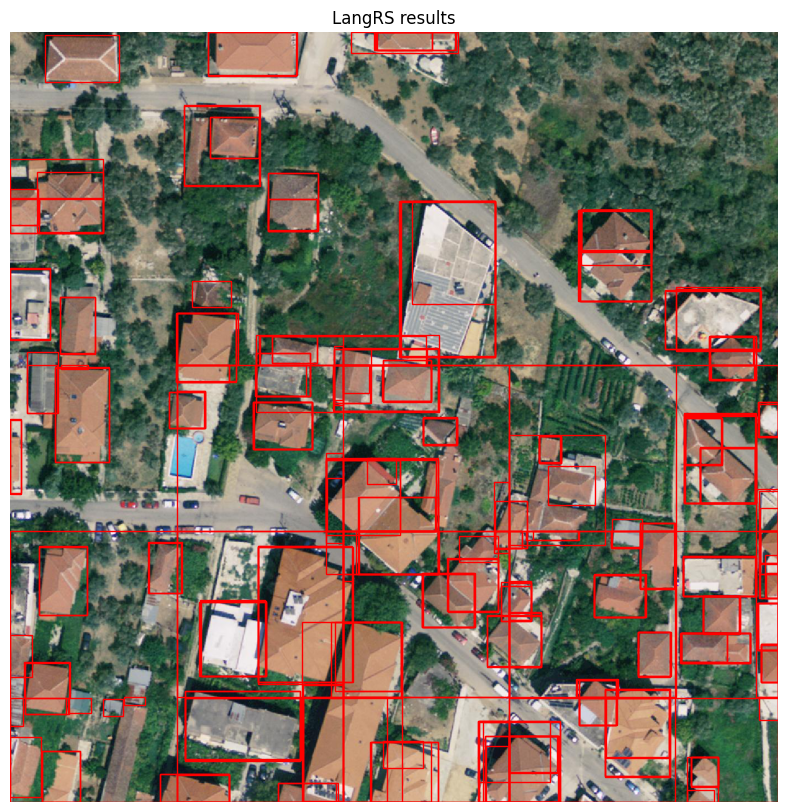

In [27]:
plot_bounding_boxes(input_image, bounding_boxes, title='LangRS results')

In [28]:
bboxes_filtered = model.outlier_rejection()

In [29]:
bboxes_filtered.keys()

dict_keys(['zscore', 'iqr', 'svm', 'svm_sgd', 'robust_covariance', 'lof', 'isolation_forest'])

All outputs are saved to the output folder

In [30]:
model.output_path

'output/20260928_112100'

We can access all the images with 'filtered' bounding boxes and visualize them.

This will allow us to qualitatively select the method with the most desirable output!

In [31]:
filtered_bb_images = []
for file in os.listdir(model.output_path):
    if 'filtered' in file:
      image_path = os.path.join(model.output_path, file)
      filtered_bb_images.append(image_path)

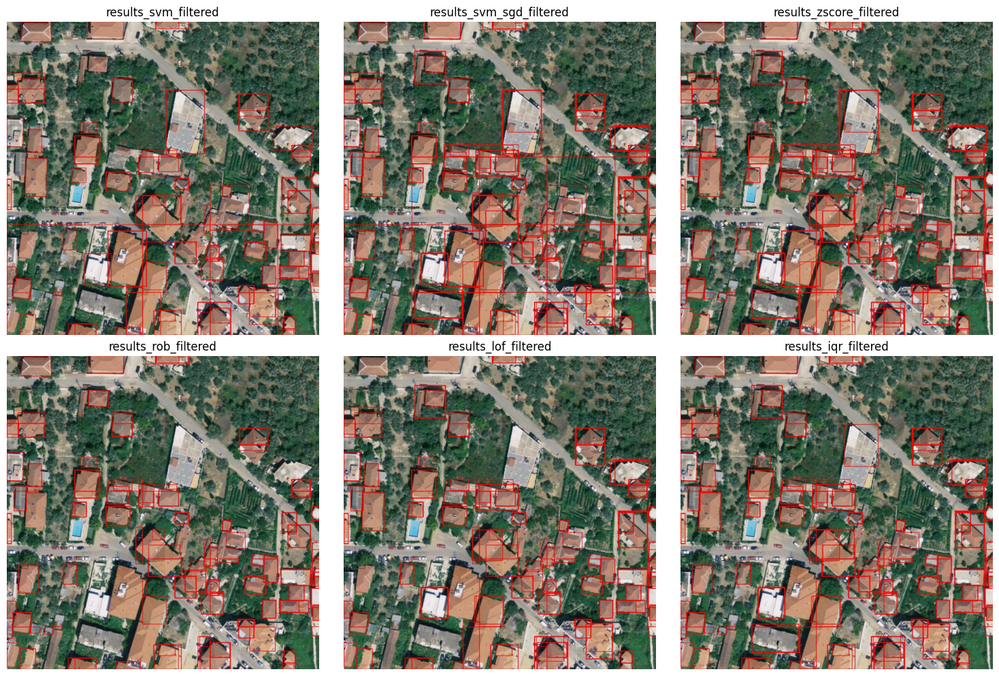

In [32]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

# Only use the first six images
image_paths = filtered_bb_images[:6]

# Create a 2x3 subplot grid
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Flatten axes for easier iteration
axes = axes.flatten()

for i, image_path in enumerate(image_paths):
    image = mpimg.imread(image_path)  # Load image
    filename = os.path.splitext(os.path.basename(image_path))[0]  # Extract filename without extension

    axes[i].imshow(image)  # Show image
    axes[i].axis('off')  # Hide axes
    axes[i].set_title(filename)  # Set title

plt.tight_layout()
plt.show()
plt.close()

In [33]:
bboxes_zscore = bboxes_filtered['zscore']

### Applying Non-Max Suppression

This method removes redundunt boxes based on an overlap region between overlapped boxes

In [34]:
from langrs.common import apply_nms

bboxes_zscore_filtered = apply_nms(bboxes_zscore, iou_threshold=0.6)

In [35]:
len(bboxes_zscore)

278

In [36]:
len(bboxes_zscore_filtered)

127

In [37]:
# Function to draw bounding boxes
def draw_bounding_boxes(ax, image, bounding_boxes, title):
    ax.imshow(image)
    ax.axis("off")
    ax.set_title(title)

    for box in bounding_boxes:
        x_min, y_min, x_max, y_max = box
        width = x_max - x_min
        height = y_max - y_min
        rect = Rectangle((x_min, y_min), width, height, linewidth=1, edgecolor='r', facecolor='none')
        ax.add_patch(rect)

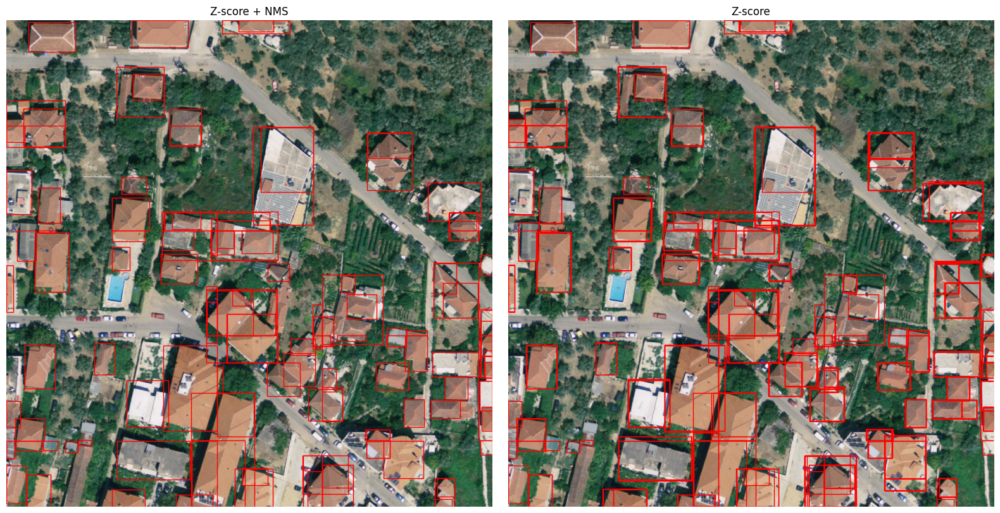

In [38]:
# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Plot the first bounding box set
draw_bounding_boxes(axes[0], input_image, bboxes_zscore_filtered, "Z-score + NMS")

# Plot the second bounding box set
draw_bounding_boxes(axes[1], input_image, bboxes_zscore, "Z-score")

plt.tight_layout()
plt.show()
plt.close()

## Comparison of LangRS and SamGeo object detection

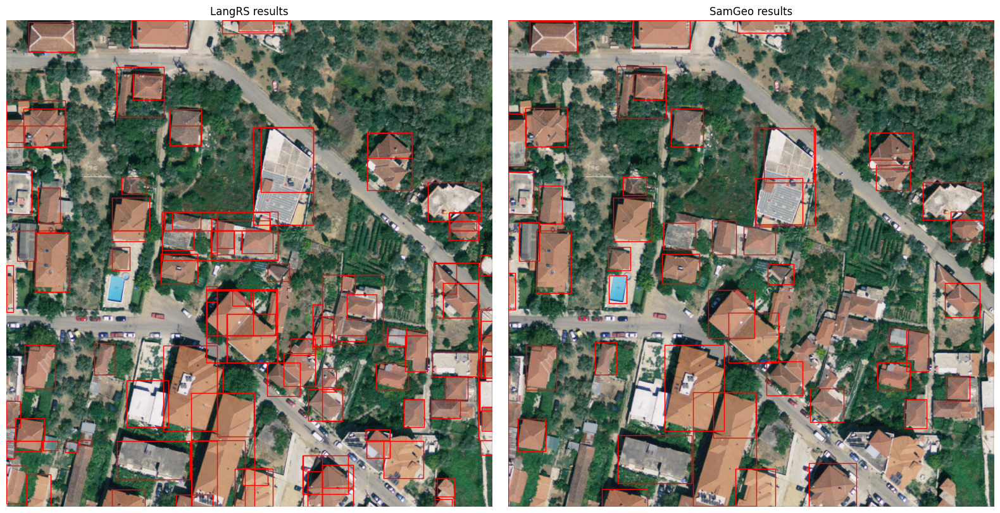

In [39]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Plot the first bounding box set
draw_bounding_boxes(axes[0], input_image, bboxes_zscore_filtered, "LangRS results")

# Plot the second bounding box set
draw_bounding_boxes(axes[1], input_image, samgeo_bb, "SamGeo results")

plt.tight_layout()
plt.show()


## Segmentation using the preferred bounding boxes set

In [40]:
masks = model.generate_masks(boxes=bboxes_zscore_filtered)

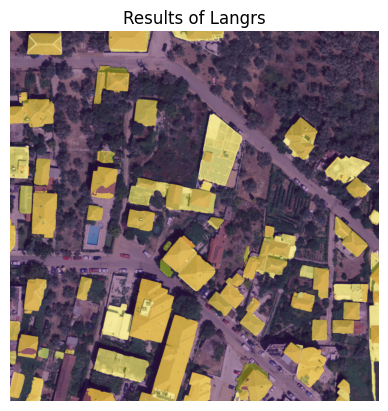

In [41]:
fig, ax = plt.subplots()
ax.imshow(input_image)
ax.imshow(masks, cmap="viridis", alpha=0.4)
ax.axis('off')  # Turn off the axes

plt.title("Results of Langrs")
plt.show()
plt.close()

#Comparison of segmentation results

In [42]:
sam_masks = samgeo_masks.any(dim=0).detach().cpu().numpy()

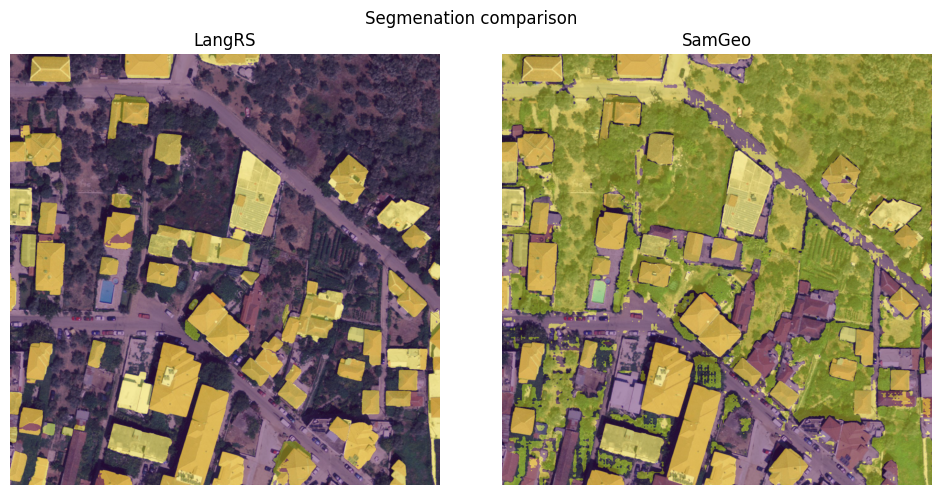

In [43]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 5))  # 1 row, 2 columns

# First image
axes[0].imshow(input_image)
axes[0].imshow(masks, cmap="viridis", alpha=0.4)
axes[0].axis('off')
axes[0].set_title("LangRS")

# Second image
axes[1].imshow(input_image)
axes[1].imshow(sam_masks, cmap="viridis", alpha=0.4)
axes[1].axis('off')
axes[1].set_title("SamGeo")

plt.suptitle("Segmenation comparison")
plt.tight_layout()
plt.show()
plt.close()

**cellule pour ajouter la génération des masques et l'export des résultats en shapefile ou GeoJSON, ce qui serait le plus utile pour un usage en topographie.**

127 boîtes envoyées à SAM


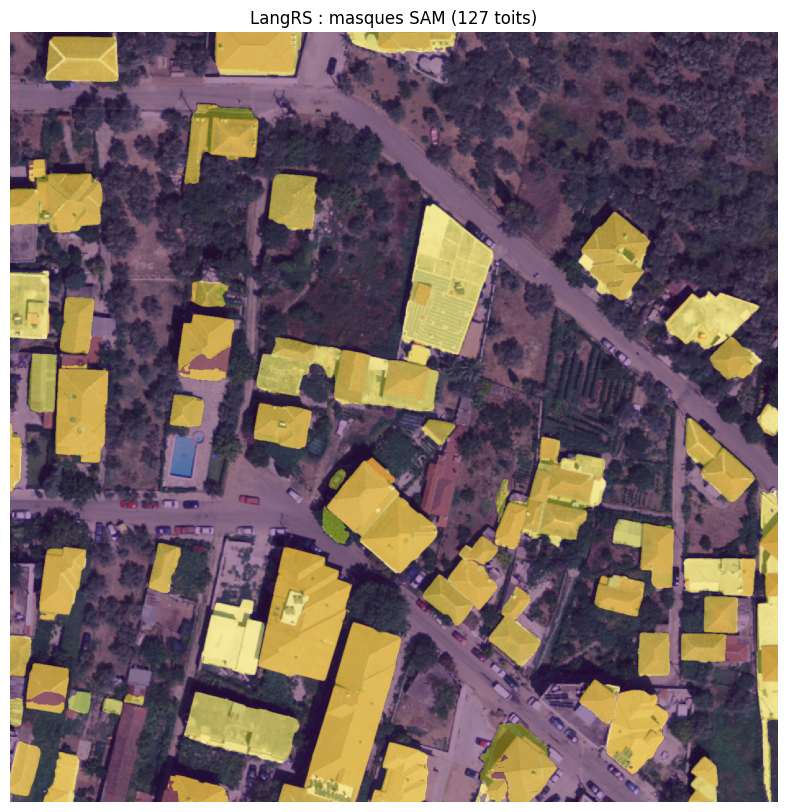

In [44]:
import numpy as np, torch, matplotlib.pyplot as plt

# apply_nms renvoie un tenseur -> on le convertit en liste de tuples
boxes = [tuple(map(float, b)) for b in torch.as_tensor(bboxes_zscore_filtered).cpu().numpy()]
print(f"{len(boxes)} boîtes envoyées à SAM")

torch.cuda.empty_cache()
mask_overlay = model.generate_masks(boxes=boxes)

fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(model.np_image)
ax.imshow(mask_overlay, cmap="viridis", alpha=0.4)
ax.axis("off")
ax.set_title(f"LangRS : masques SAM ({len(boxes)} toits)")
plt.show()

In [45]:
import rasterio, geopandas as gpd
from rasterio.features import shapes
from shapely.geometry import shape

with rasterio.open(model.image_path) as src:
    transform, crs = src.transform, src.crs

polys, ids = [], []
for i, m in enumerate(model.masks):
    m = m.cpu().numpy() if isinstance(m, torch.Tensor) else np.asarray(m)
    m = (m > 0).astype(np.uint8)
    for geom, _ in shapes(m, mask=m.astype(bool), transform=transform):
        polys.append(shape(geom))
        ids.append(i + 1)

gdf = gpd.GeoDataFrame({"id": ids}, geometry=polys, crs=crs)
gdf = gdf.dissolve(by="id").reset_index()          # 1 géométrie par toit

# Surface en m² : il faut un CRS projeté (en mètres)
gdf_proj = gdf if gdf.crs.is_projected else gdf.to_crs(gdf.estimate_utm_crs())
gdf["area_m2"] = gdf_proj.area.round(2)

print(f"CRS de l'image : {crs}")
print(f"{len(gdf)} toits | surface médiane : {gdf['area_m2'].median():.1f} m²")
gdf.head()

CRS de l'image : EPSG:2100
127 toits | surface médiane : 63.0 m²


,id,geometry,area_m2
0,1,"POLYGON ((424072.551 4350949.292, 424072.551 4...",4.11
1,2,"POLYGON ((424082.605 4350870.576, 424082.605 4...",9.31
2,3,"POLYGON ((424176.006 4350909.074, 424176.006 4...",5.20
3,4,"POLYGON ((424170.45 4350909.074, 424170.45 435...",7.95
4,5,"MULTIPOLYGON (((424206.434 4350911.323, 424206...",2.98


In [49]:
import os
out = os.path.join(model.output_path, "toits")
os.makedirs(out, exist_ok=True)

gdf.to_file(os.path.join(out, "toits.shp"))                       # ArcGIS / QGIS classique
gdf.to_file(os.path.join(out, "toits.gpkg"), driver="GPKG")       # recommandé (pas de limite de noms de champs)
gdf.to_crs(4326).to_file(os.path.join(out, "toits.geojson"), driver="GeoJSON")  # web (WGS84)

# Tout zipper et télécharger
import shutil
from google.colab import files
zip_path = shutil.make_archive("resultats_langrs", "zip", model.output_path)
files.download(zip_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>